# Lösung zu Megatutorial 1

Unterhalb findet ihr die Tools, die wir im MT verwenden. Darüber hinaus gibt es einige Optionen, die wir außerdem importieren könnten, um unseren Code "explizit" zu gestalten. Diese Importe sind aber optional, weil `tensorflow` für uns mitdenkt. So können wir z. B. einen Dense layer entweder so `Dense(5, activation="relu")` oder so `Dense(5, activation=relu)` definieren. Damit die zweite Option aber funktioniert, müssen wir die `relu`-Funktion aber zuerst importieren (`from tensorflow.keras.activations import relu`). Hier sind einige optionale Importe die ihr noch verwenden könntet:

```python
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.metrics import sparse_categorical_accuracy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import relu, softmax
```

In [19]:
from matplotlib import pyplot as plt
from numpy import array
from pandas import DataFrame

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Das habe ich noch neu eingefügt. Damit legen wir fest, wie tensorflow
# zu seinen initialen Gewichten kommt; und so bekommen wir dann auch
# alle denselben Loss-Verlauf und letztlich auch reproduzierbare
# Ergebnisse.

from tensorflow.random import set_seed

set_seed(123)

## Feature Extraction

Hier haben wir unsere Daten definiert. Wir haben dazu das gegebene Szenario in ein multidimensionales `numpy`-Array überführt. Jede zeile dieses Arrays stellt einen Datensatz dar. Jeder Datensatz enthält genau drei werte - Tempereaturalarm (`0`/`1`), Öldruckalarm (`0`/`1`) und Vibrationsalarm (`0`/`1`).

Unser Target-Vektor enthält zu jeder `X`-Zeile den passenden Zielwert. Dieser ist ebenfalls binär-codiert und ist `0`, wenn die Maschine problemlos weiterläuft, oder `1`, wenn die Maschine ausfällt. Diese Darstellungesweise nennen wir "sparse". Jeder Wert des Vektors beschreibt die Zielklasse des dazugehörigen `X`-Werts. Die Darstellung erfolgt aber nummerisch, wobei jede Nummer eine Klasse repräsentiert. Das spart Platz und darum nennen wir es "sparse". Diese Info ist deshalb wichtig, weil wir passend hierzu auch bei der Loss-Funktion die sparse Variante verwenden (`sparse_categorical_crossentropy`).

Die Alternative Darstellung von `y` ist die One-Hot-Form. Hier würden wir für jeden `y`-Wert eine Bitmap verwenden die durch `0` oder `1` anzeigt, welche Klasse hier vorliegt. Das würde dann so aussehen:

```python
y = array([
    [1, 0], # hier ist KLasse 0 aktiv
    [1, 0], # hier ist KLasse 0 aktiv
    [1, 0], # hier ist KLasse 0 aktiv
    [0, 1], # hier ist KLasse 1 aktiv
    [1, 0], # hier ist KLasse 0 aktiv
    [0, 1], # hier ist KLasse 1 aktiv
    [0, 1], # hier ist KLasse 1 aktiv
    [0, 1], # hier ist KLasse 1 aktiv
])
```

Diese Darstellung ist aufwändiger, aber genauso richtig. Wenn wir uns entscheiden würden, diese Darstellung zu verwenden, müssten wir aber unsere Loss-Funktion ebenfalls anpassen. In diesem Fall würden wir die `categorical_crossentropy` verwenden.

In [3]:
X = array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

y = array([0, 0, 0, 1, 0, 1, 1, 1])

Hier hatten wir noch die Form unserer beiden Objekte überprüft. Das ist ein wichtiger Schritt beim Deep-Learning, weil `tensorflow` (und `torch`) eine bestimmte Form der Input-Daten und des Target-Vektors erwartet. Näheres Dazu besprechen wir beim nächsten Mal. 

In [4]:
X.shape, y.shape

((8, 3), (8,))

## Model Setup

Hier hatten wir unser Modell definiert. Wir verwenden hier eine Input-Schicht, die unsere Datensätze entgegennimmt (und 3 Werte je Datensatz erwartet); und wir verwenden zwei voll vernetzte Schichten (in `tensorflow` werden diese `Dense` genannt). Die erste der beiden hat bei uns `5` künstliche Neuronen und verwendet die `relu`-Aktivierungsfunktion. Anstelle von `5` hätten wir auch jeden anderen Wert verwenden können. Wir achten aber darauf weder zu schmal (z. B. `1`) noch zu breit (z. B. `100`) zu sein. Ob dieser Wert Sinn macht, sehen wir spätestens beim Training, wenn wir den Loss analysieren.

>**Loss und Neuronenzahl:** Wir wollen, dass unser Loss im Training fällt und gegen einen Wert konvergiert. Fällt der Loss nicht ab, oder entwickelt er sich auf andere Weise unverständlich, sollten wir unser Netz-Setup überprüfen. Dazu gehört unter anderem auch die Breite unserer Layer. Leider ist das aber nicht die einzige Stelle, wo etwas schief gehen kann. Die Layer-Breite würde ich mir aber jedenfalls als eine der Ersten Einstellmöglichkeiten anschauen, wenn das Training nicht gut läuft.

Die zweite Schicht, die gleichzeitig unseren Output generiert hat 2 Neuronen. Diese Zahl ist nicht zufällig gewählt, sondern entspricht exakt der Anzahl an Klassen, die wir im Target-Vektor (`y`) finden.

In [5]:
model = Sequential()

model.add(Input(shape=[3]))
model.add(Dense(5, activation="relu"))
model.add(Dense(2, activation="softmax"))

Hier sehen wir unser Netz noch im Überblick. Wir sehen die breite der einzelnen Layer und die sich daraus ergebende Menge an trainierbaren Parametern. Unser erster `Dense`-Layer hat z. B. `3 * 15` Basisgewichte. Dazu kommen dann noch einmal `5` Bias-Gewichte. Das insgesamt `20` trainierbare Parameter. Unser Netz hat aktuell keine nicht-trainierbaren Parameter. Die würde es nur dann geben, wenn wir die Trainierbarkeit von einzelnen Layern wie folgt ausschalten würden:

```python
model.layers[0].trainable = False
```

Hier habe ich z. B. den ersten Layer unseres Netzes für's Training deaktiviert. Das ist in einfachen Netzen eher unüblich, spielt aber beim Transfer-Learning eine große Rolle. Dort nehmen wir uns fertig trainierte Netze (z. B. Bildklassifizierungsnetze wie `RESNET` oder `VGG16`), und adaptieren sie durch partielles Training für unsere Zwecke, ohne das ganze Netz neu trainieren zu müssen.

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

Für das Training haben wir unsere Netz einen Trainer (`Adam()`) zur Seite gestellt. Dieser Optimizer arbeitet nach dem Gradient Descent Prinzip, hat aber noch zwei zusätzliche "gute" Eigenschaften: Er passt die Lernrate adaptiv an und beschleunigt so das Training und er arbeitet mit Momentum, um nicht an lokalen Minima/Maxima hängen zu bleiben.

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

Die `fit()`-Methode ruft unser eigentliches Training auf. Hier geben wir dem Netz unsere Daten und Targets, sowie einige Vorgaben hinsichtlich seiner "Gesprächigkeit" (`verbose`) und der Trainingslänge (`epochs`) und lassen den Optimizer seinen Job machen. Das Training gibt uns dabei Rückgabewerte zu unserem Loss und etwaigen Metriken, die wir mitloggen lassen. Diese speichern wir uns im `log`-Objekt. So können wir die Loss-Entwicklung später visualisieren.

In [8]:
log = model.fit(
    X, y,
    epochs=2000,
    verbose=0,
    callbacks=[EarlyStopping()]
)

/Users/michaelkohlegger/Documents/GitHub/industrial_computing_dibse_26/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


## Model Evaluation

Hier haben wir die Loss-Entwicklung visualisiert. Was wir sehen wollen, ist eine schön fallende und im hinteren Trainingsbereich degressiv verlaufende Kurve, die gegen einen Wert (der nicht immer `0` sein muss!) konvergiert. Wenn wir das sehen, sind wir happy 😍.

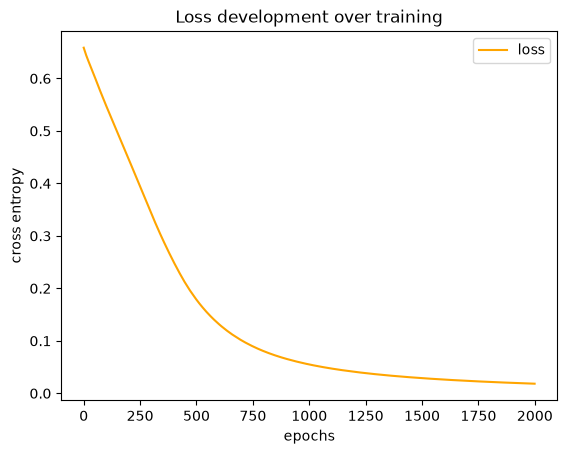

In [9]:
plt.plot(log.history["loss"], label="loss", color="orange")
plt.title("Loss development over training")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.legend(loc=0)
plt.show()

## Model Use

Hier hatten wir unser Model nach dem Training verwendet, um unsere Datensätze zu klassifizieren. Das funktioniert, wie wir sehen, wunderbar. Jeder Datensatz erhält die Richtige Klasse. Dabei stellen die angezeigten Werte je Zeile die Wahrscheinlichkeiten dar mit den die beiden Klassen `0` und `1` vorliegen. Diese Wahrscheinlichkeiten ergeben `1` oder `100 %`, wenn man sie alle addiert. Dafür hat unsere `softmax`-Funktion gesorgt.

In [ ]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[9.9554288e-01, 4.4570435e-03],
       [9.9011171e-01, 9.8882644e-03],
       [8.9631099e-01, 1.0368901e-01],
       [2.3894622e-03, 9.9761057e-01],
       [9.9103981e-01, 8.9602172e-03],
       [8.0615040e-03, 9.9193853e-01],
       [2.9234483e-03, 9.9707651e-01],
       [1.9440418e-07, 9.9999976e-01]], dtype=float32)

Wir hatten gesehen, dass wir unser Modell sofort nach dem Erstellen schon vollumfänglich anwenden können. Zu diesem Punkt machen die Schätzungen, die wir bekommen, aber noch keinen Sinn. Das Modell kann die Zielklassen noch nicht unterscheiden. Das liegt daran, dass die Gewichte unseres Modells hier noch nicht trainiert sind.

In [ ]:
predictions = model.predict(X)
result = DataFrame(predictions, columns=["prob_class_0", "prob_class_1"])
result["sum"] = result["prob_class_0"] + result["prob_class_1"]
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,prob_class_0,prob_class_1,sum
0,9.955429e-01,0.004457,1.0
1,9.901117e-01,0.009888,1.0
2,8.963110e-01,0.103689,1.0
3,2.389462e-03,0.997611,1.0
4,9.910398e-01,0.008960,1.0
5,8.061504e-03,0.991939,1.0
6,2.923448e-03,0.997077,1.0
7,1.944042e-07,1.000000,1.0
